# Installing dependencies

In [1]:
!pip install torch torchvision torchaudio
!pip install scipy matplotlib pandas numpy scikit-learn
!pip install kaggle  # If downloading from Kaggle
from sklearn.utils.class_weight import compute_class_weight
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F

# 1. Fix protobuf version
!pip uninstall -y protobuf google-protobuf
!pip install protobuf==4.25.3 --force-reinstall

# 2. Reinstall key packages
!pip uninstall -y onnx onnxruntime onnx2tf tensorflow
!pip install onnx onnxruntime onnx2tf tensorflow==2.19.0 --no-cache-dir

print("✅ Environment fixed!")

!pip install torchviz graphviz pydot -q
!apt-get install graphviz -y -q

Found existing installation: protobuf 4.25.5
Uninstalling protobuf-4.25.5:
  Successfully uninstalled protobuf-4.25.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnx2tf 2.4.0 requires protobuf==4.25.5, but you have protobuf 4.25.3 which is incompatible.
google-cloud-bigquery-storage 2.37.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.3 which is incompatible.
google-cloud-dataplex 2.18.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-bigquery-connection 1.21.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
googleapis-common-protos 1.74.0 requires protobuf<8.0.0,>=4.25.8, but you

Found existing installation: onnx 1.20.1
Uninstalling onnx-1.20.1:
  Successfully uninstalled onnx-1.20.1
Found existing installation: onnxruntime 1.24.3
Uninstalling onnxruntime-1.24.3:
  Successfully uninstalled onnxruntime-1.24.3
Found existing installation: onnx2tf 2.4.0
Uninstalling onnx2tf-2.4.0:
  Successfully uninstalled onnx2tf-2.4.0
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 250.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 242.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 

✅ Environment fixed!
Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


# Mount Drive & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

data_dir = '/content/drive/MyDrive/EEG Dataset/sam40'
print("Folders:", os.listdir(data_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders: ['Mirror_image-20231211T181915Z-001', 'Relax-20231211T181913Z-001', 'Arithmetic-20231211T181918Z-001', 'Stroop-20231211T181911Z-001']


# Define Folders & Parameters

In [3]:
# Folder names (from your output)
relax_folder = [f for f in os.listdir(data_dir) if 'Relax' in f][0]
stroop_folder = [f for f in os.listdir(data_dir) if 'Stroop' in f][0]
arithmetic_folder = [f for f in os.listdir(data_dir) if 'Arithmetic' in f][0]
mirror_folder = [f for f in os.listdir(data_dir) if 'Mirror_image' in f][0]

relax_path = os.path.join(data_dir, relax_folder, 'Relax')
stroop_path = os.path.join(data_dir, stroop_folder, 'Stroop')
arithmetic_path = os.path.join(data_dir, arithmetic_folder, 'Arithmetic')
mirror_path = os.path.join(data_dir, mirror_folder, 'Mirror_image')

# Parameters ────────────────────────────────────────────────────────────────
CHANNEL_INDEX     = 2          # Fp1 (keep)
WINDOW_SIZE_ORIG  = 768        # ← increased from 512 (≈6 seconds @128 Hz)
STRIDE            = 256        # keep 50% overlap
TARGET_WINDOW_SIZE = 64        # ← increased from 32 (better temporal context)
SAMPLING_RATE     = 128

# Load & Preprocess Function

In [4]:
from scipy.signal import resample

def load_and_segment(folder_path, label, augment_prob=0.5):
    windows = []
    labels = []
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"Loading {len(csv_files)} files from {os.path.basename(folder_path)} (label={label})")

    for csv_file in csv_files:
        df = pd.read_csv(os.path.join(folder_path, csv_file))
        eeg = df[str(CHANNEL_INDEX)].values.astype(float)  # safer than hard-coded '2'

        for start in range(0, len(eeg) - WINDOW_SIZE_ORIG, STRIDE):
            window = eeg[start:start + WINDOW_SIZE_ORIG].copy()

            # Normalize
            if len(window) == WINDOW_SIZE_ORIG:
                scaler = StandardScaler()
                window_norm = scaler.fit_transform(window.reshape(-1, 1)).flatten()

                # Augmentation: add Gaussian noise (simulate motion/vibration)
                if np.random.rand() < augment_prob:
                    noise_level = np.random.uniform(0.08, 0.25)  # tune between 8–25%
                    noise = np.random.normal(0, noise_level, len(window_norm))
                    window_norm += noise

                # Resample to target length
                window_resampled = resample(window_norm, TARGET_WINDOW_SIZE)
                windows.append(window_resampled)
                labels.append(label)

    return np.array(windows), np.array(labels)

# Load all data
X_relax, y_relax = load_and_segment(relax_path, 0, augment_prob=0.4)

X_stress = []
y_stress = []
for stress_path, name in [(stroop_path, "Stroop"), (arithmetic_path, "Arithmetic"), (mirror_path, "Mirror")]:
    X_s, y_s = load_and_segment(stress_path, 1, augment_prob=0.65)  # more noise for stress
    X_stress.append(X_s)
    y_stress.append(y_s)

X_stress = np.concatenate(X_stress)
y_stress = np.concatenate(y_stress)

# Combine
# ────────────────────────────────────────────────────────────────
# After combining X and y (your current code)
# ────────────────────────────────────────────────────────────────

X = np.concatenate([X_relax, X_stress])
y = np.concatenate([y_relax, y_stress])

print(f"Total windows: {len(X)} (Relax: {len(X_relax)}, Stress: {len(X_stress)})")
print(f"Shape per window: {X.shape[1]} samples")

# ────────────────────────────────────────────────────────────────
# Define device FIRST (very important!)
# ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Now safely compute and move class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)  # e.g. tensor([2.0000, 0.6667], device='cuda:0')

Loading 39 files from Relax (label=0)
Loading 40 files from Stroop (label=1)
Loading 37 files from Arithmetic (label=1)
Loading 40 files from Mirror_image (label=1)
Total windows: 5460 (Relax: 1365, Stress: 4095)
Shape per window: 64 samples
Using device: cpu
Class weights: tensor([2.0000, 0.6667])


# Split & Create DataLoaders

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# To PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (batch, 1, 32)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# Define Lightweight CNN Model

In [6]:
class ImprovedStressCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,  24, kernel_size=5, stride=1, padding=2)
        self.bn1   = nn.BatchNorm1d(24)
        self.conv2 = nn.Conv1d(24, 48, kernel_size=5, stride=1, padding=2)
        self.bn2   = nn.BatchNorm1d(48)
        self.conv3 = nn.Conv1d(48, 96, kernel_size=3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm1d(96)

        # Global average pooling → no need to hardcode fc input size
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc1   = nn.Linear(96, 64)
        self.drop  = nn.Dropout(0.45)
        self.fc2   = nn.Linear(64, 2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.gap(x).squeeze(-1)        # (batch, 96)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

# Convert to PyTorch tensor ONCE and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights (tensor):", class_weights_tensor)

# Model, loss, optimizer, scheduler
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedStressCNN().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)          # ← fixed here

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
print(model)

Class weights (tensor): tensor([2.0000, 0.6667])
ImprovedStressCNN(
  (conv1): Conv1d(1, 24, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(24, 48, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(48, 96, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=96, out_features=64, bias=True)
  (drop): Dropout(p=0.45, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


# Train the Model

In [7]:
best_acc = 0.0
for epoch in range(50):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:           # ← this now exists
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    preds = []
    true = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true.extend(labels.numpy())

    acc = accuracy_score(true, preds)
    print(f"Epoch {epoch+1:2d} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}")

    scheduler.step(acc)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/eeg_stress_model_best.pth')
        print(f"→ New best model saved (acc={acc:.4f})")

print(f"Best validation accuracy achieved: {best_acc:.4f}")

Epoch  1 | Loss: 0.6716 | Val Acc: 0.5888
→ New best model saved (acc=0.5888)
Epoch  2 | Loss: 0.6453 | Val Acc: 0.7079
→ New best model saved (acc=0.7079)
Epoch  3 | Loss: 0.6294 | Val Acc: 0.6264
Epoch  4 | Loss: 0.6220 | Val Acc: 0.6282
Epoch  5 | Loss: 0.6187 | Val Acc: 0.7445
→ New best model saved (acc=0.7445)
Epoch  6 | Loss: 0.6191 | Val Acc: 0.7170
Epoch  7 | Loss: 0.6107 | Val Acc: 0.7115
Epoch  8 | Loss: 0.6045 | Val Acc: 0.6630
Epoch  9 | Loss: 0.6031 | Val Acc: 0.6667
Epoch 10 | Loss: 0.6031 | Val Acc: 0.6255
Epoch 11 | Loss: 0.5970 | Val Acc: 0.7372
Epoch 12 | Loss: 0.5914 | Val Acc: 0.6822
Epoch 13 | Loss: 0.5935 | Val Acc: 0.7170
Epoch 14 | Loss: 0.5854 | Val Acc: 0.7225
Epoch 15 | Loss: 0.5804 | Val Acc: 0.6575
Epoch 16 | Loss: 0.5780 | Val Acc: 0.6896
Epoch 17 | Loss: 0.5714 | Val Acc: 0.6584
Epoch 18 | Loss: 0.5669 | Val Acc: 0.6090
Epoch 19 | Loss: 0.5701 | Val Acc: 0.6392
Epoch 20 | Loss: 0.5667 | Val Acc: 0.6090
Epoch 21 | Loss: 0.5656 | Val Acc: 0.6960
Epoch 22 |

# Final Evaluation & Save Model

In [8]:
# ────────────────────────────────────────────────────────────────
# Final Evaluation on the last validation batch
# (Note: this uses the very last preds/true — for real final eval you might want to run a separate loop)
# ────────────────────────────────────────────────────────────────
print("Final Report (last validation):")
print(classification_report(true, preds, target_names=['Relax', 'Stress'], digits=3))

# ────────────────────────────────────────────────────────────────
# Save the CURRENT model (but we already saved the best one during training)
# This is optional — you can skip or rename if you want a final snapshot
# ────────────────────────────────────────────────────────────────
torch.save(model.state_dict(), '/content/drive/MyDrive/eeg_stress_model_final_snapshot.pth')
print("Final snapshot saved!")

Final Report (last validation):
              precision    recall  f1-score   support

       Relax      0.411     0.645     0.502       273
      Stress      0.854     0.692     0.765       819

    accuracy                          0.680      1092
   macro avg      0.633     0.668     0.633      1092
weighted avg      0.743     0.680     0.699      1092

Final snapshot saved!


# Model class

In [9]:
# ────────────────────────────────────────────────────────────────
# Load the BEST model we saved during training
# ────────────────────────────────────────────────────────────────
import torch

# Use the IMPROVED model class
model = ImprovedStressCNN()

# Load the best checkpoint (the one saved when validation acc was highest)
best_checkpoint_path = '/content/drive/MyDrive/eeg_stress_model_best.pth'

try:
    model.load_state_dict(
        torch.load(best_checkpoint_path, map_location='cpu')
    )
    print(f"Successfully loaded best model from: {best_checkpoint_path}")
except Exception as e:
    print(f"Error loading best model: {e}")
    print("Falling back to last trained model...")
    model.load_state_dict(
        torch.load('/content/drive/MyDrive/eeg_stress_model_final_snapshot.pth', map_location='cpu')
    )

model.eval()

Successfully loaded best model from: /content/drive/MyDrive/eeg_stress_model_best.pth


ImprovedStressCNN(
  (conv1): Conv1d(1, 24, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(24, 48, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(48, 96, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=96, out_features=64, bias=True)
  (drop): Dropout(p=0.45, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

# Install stable AI Edge Torch


In [10]:
# # Clean uninstall old stuff
# !pip uninstall -y onnx onnx-tf onnxruntime tensorflow-addons

# Quick test import
try:
    import onnx2tf
    print("SUCCESS: onnx2tf imported OK! (modern converter)")
except Exception as e:
    print("Import failed:", str(e))

SUCCESS: onnx2tf imported OK! (modern converter)


In [11]:
import torch
from torchviz import make_dot
import matplotlib.pyplot as plt

# Load your best model
model = ImprovedStressCNN()
model.load_state_dict(torch.load('/content/drive/MyDrive/eeg_stress_model_best.pth', map_location='cpu'))
model.eval()

# Dummy input
x = torch.randn(1, 1, 64, requires_grad=True)

# Forward pass
y = model(x)

# Create diagram
dot = make_dot(y, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
dot.format = 'png'
dot.render('/content/drive/MyDrive/model_architecture')

print("✅ Model architecture saved as: model_architecture.png")

✅ Model architecture saved as: model_architecture.png


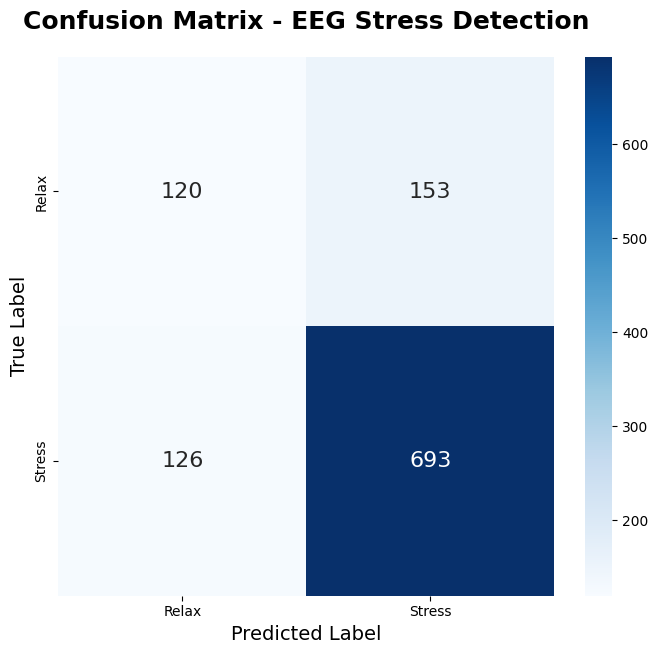

              precision    recall  f1-score   support

       Relax     0.4878    0.4396    0.4624       273
      Stress     0.8191    0.8462    0.8324       819

    accuracy                         0.7445      1092
   macro avg     0.6535    0.6429    0.6474      1092
weighted avg     0.7363    0.7445    0.7399      1092



In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Relax', 'Stress'],
            yticklabels=['Relax', 'Stress'],
            annot_kws={"size": 16})

plt.title('Confusion Matrix - EEG Stress Detection', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed report
print(classification_report(all_labels, all_preds, target_names=['Relax', 'Stress'], digits=4))

In [13]:
# ====================== TRAINING WITH HISTORY ======================
history = {'train_loss': [], 'val_acc': [], 'val_loss': []}
best_acc = 0.0

for epoch in range(50):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation Phase
    model.eval()
    val_loss = 0.0
    preds = []
    true = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true.extend(labels.cpu().numpy())

    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_acc = accuracy_score(true, preds)

    # Save history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_acc)

    print(f"Epoch {epoch+1:2d} | Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_acc:.4f}")

    scheduler.step(epoch_acc)

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/eeg_stress_model_best.pth')
        print(f"→ New best model saved (acc={epoch_acc:.4f})")

print(f"\nBest validation accuracy: {best_acc:.4f}")

Epoch  1 | Train Loss: 0.6127 | Val Loss: 0.6158 | Val Acc: 0.6886
→ New best model saved (acc=0.6886)
Epoch  2 | Train Loss: 0.6157 | Val Loss: 0.6157 | Val Acc: 0.6914
→ New best model saved (acc=0.6914)
Epoch  3 | Train Loss: 0.6179 | Val Loss: 0.6171 | Val Acc: 0.6841
Epoch  4 | Train Loss: 0.6161 | Val Loss: 0.6163 | Val Acc: 0.6850
Epoch  5 | Train Loss: 0.6181 | Val Loss: 0.6161 | Val Acc: 0.6932
→ New best model saved (acc=0.6932)
Epoch  6 | Train Loss: 0.6150 | Val Loss: 0.6170 | Val Acc: 0.6877
Epoch  7 | Train Loss: 0.6109 | Val Loss: 0.6170 | Val Acc: 0.6859
Epoch  8 | Train Loss: 0.6186 | Val Loss: 0.6174 | Val Acc: 0.6795
Epoch  9 | Train Loss: 0.6165 | Val Loss: 0.6174 | Val Acc: 0.6777
Epoch 10 | Train Loss: 0.6182 | Val Loss: 0.6176 | Val Acc: 0.6767
Epoch 11 | Train Loss: 0.6165 | Val Loss: 0.6161 | Val Acc: 0.6896
Epoch 12 | Train Loss: 0.6188 | Val Loss: 0.6155 | Val Acc: 0.6886
Epoch 13 | Train Loss: 0.6135 | Val Loss: 0.6169 | Val Acc: 0.6841
Epoch 14 | Train Loss

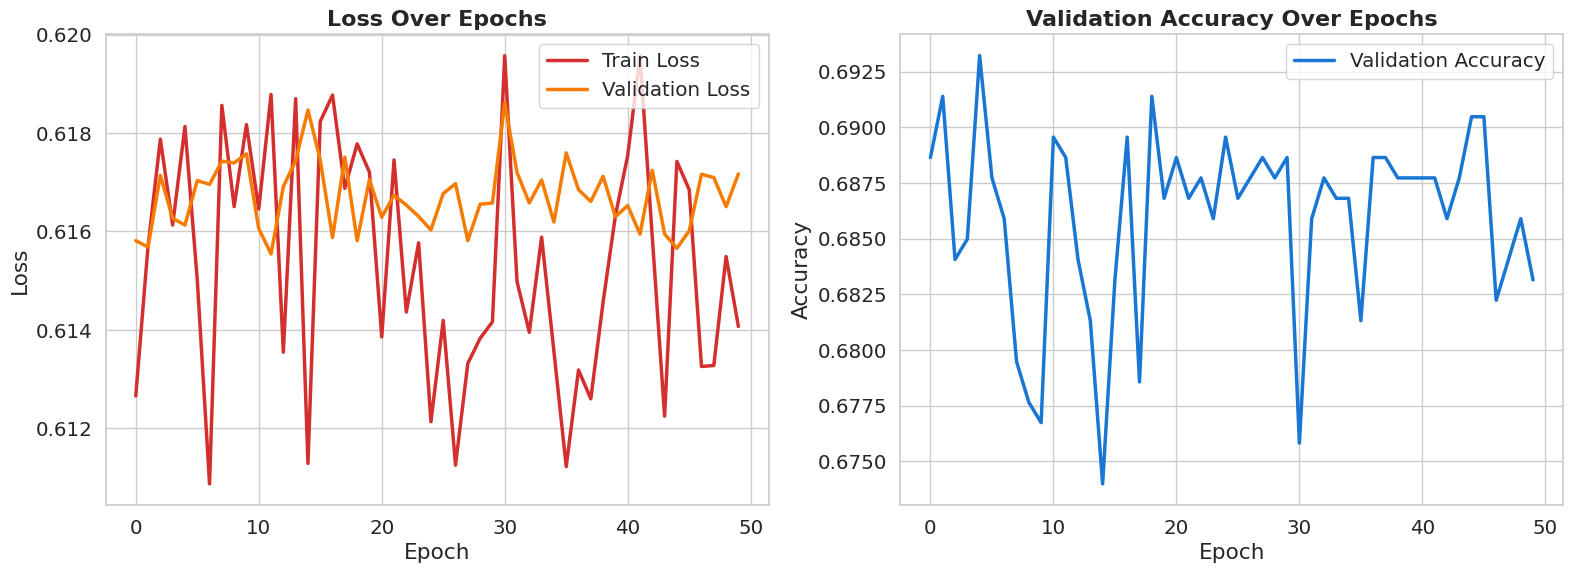

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.3)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Loss Curves
ax[0].plot(history['train_loss'], label='Train Loss', linewidth=2.5, color='#d32f2f')
ax[0].plot(history['val_loss'], label='Validation Loss', linewidth=2.5, color='#f57c00')
ax[0].set_title('Loss Over Epochs', fontsize=16, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy Curve
ax[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2.5, color='#1976d2')
ax[1].set_title('Validation Accuracy Over Epochs', fontsize=16, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Convert to TFLite

In [15]:
import torch
import onnx
import onnx2tf
import tensorflow as tf
import os

# Model prep
model.to('cpu')
model.eval()

# Dummy input (adjust 64 if your TARGET_WINDOW_SIZE is different)
dummy_input = torch.randn(1, 1, 64)

# Export to ONNX
onnx_path = "eeg_stress_model.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}}
)

print(f"ONNX exported: {onnx_path}")

# Use a CLEAN subfolder to avoid conflicts
output_dir = "/content/drive/MyDrive/eeg_model_conversion_output"
os.makedirs(output_dir, exist_ok=True)
print(f"Output folder: {output_dir}")
print("Before conversion - folder contents:", os.listdir(output_dir))

# Convert (float32 version first)
tflite_float32 = os.path.join(output_dir, "eeg_stress_float32.tflite")

try:
    onnx2tf.convert(
        input_onnx_file_path=onnx_path,
        output_folder_path=output_dir,
        output_integer_quantized_tflite=False,
        non_verbose=True
    )

    # onnx2tf usually saves as 'model_float32.tflite'
    default_generated = os.path.join(output_dir, "model_float32.tflite")
    if os.path.exists(default_generated):
        os.rename(default_generated, tflite_float32)
        print(f"Float32 TFLite generated and renamed: {tflite_float32}")
    else:
        print("No model_float32.tflite found. Check folder contents after conversion:")
        print(os.listdir(output_dir))

except Exception as e:
    print(f"Float32 conversion failed: {str(e)}")

# Optional: Try integer quantization if float32 fails or for smaller size
tflite_int8 = os.path.join(output_dir, "eeg_stress_int8.tflite")
try:
    onnx2tf.convert(
        input_onnx_file_path=onnx_path,
        output_folder_path=output_dir,
        output_integer_quantized_tflite=True,
        non_verbose=True
    )
    default_quant = os.path.join(output_dir, "model_integer_quant.tflite")  # common name for quantized
    if os.path.exists(default_quant):
        os.rename(default_quant, tflite_int8)
        print(f"INT8 quantized TFLite generated: {tflite_int8}")
    else:
        print("Quantized file not found. Folder contents:", os.listdir(output_dir))
except Exception as e:
    print(f"INT8 conversion failed (optional): {str(e)}")

# Final check - look for any .tflite in the folder
print("\nAfter conversion - folder contents:")
print(os.listdir(output_dir))

tflite_final = tflite_float32 if os.path.exists(tflite_float32) else tflite_int8 if os.path.exists(tflite_int8) else None
if tflite_final:
    print(f"\nSUCCESS! Found TFLite: {tflite_final}")
    print(f"Size: {os.path.getsize(tflite_final) / 1024:.1f} KB")

    # Validate
    interpreter = tf.lite.Interpreter(model_path=tflite_final)
    interpreter.allocate_tensors()
    print("TFLite interpreter loaded successfully → ready for Flutter!")
else:
    print("No TFLite file generated. Check onnx2tf output above or folder manually.")

W0503 07:19:32.467000 12691 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ImprovedStressCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ImprovedStressCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 3 of general pattern rewrite rules.
ONNX exported: eeg_stress_model.onnx
Output folder: /content/drive/MyDrive/eeg_model_conversion_output
Before conversion - folder contents: ['variables', 'assets', 'eeg_stress_model_float32.tflite', 'eeg_stress_model_float16.tflite', 'fingerprint.pb', 'saved_model.pb']


flatbuffer_direct lowering:   0%|          | 0/12 [00:00<?, ?it/s]

...

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=1.416s serialize=0.008s (sanitize=0.000s build=0.001s pack=0.007s output=0.000s) write=1.406s size=0.11MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.753s serialize=0.008s (sanitize=0.000s build=0.001s pack=0.007s output=0.000s) write=0.743s size=0.06MB
No model_float32.tflite found. Check folder contents after conversion:
['variables', 'assets', 'eeg_stress_model_float32.tflite', 'eeg_stress_model_float16.tflite', 'fingerprint.pb', 'saved_model.pb', 'schema_generated.py', 'schema.fbs', 'eeg_stress_model_tensor_correspondence_report.json']


flatbuffer_direct lowering:   0%|          | 0/12 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/7 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.029s serialize=0.009s (sanitize=0.000s build=0.001s pack=0.008s output=0.000s) write=0.019s size=0.11MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.020s serialize=0.007s (sanitize=0.000s build=0.001s pack=0.006s output=0.000s) write=0.010s size=0.06MB
flatbuffer_direct write timing: stage=integer_quant mode=builder_direct total=0.023s serialize=0.010s (sanitize=0.000s build=0.001s pack=0.009s output=0.000s) write=0.012s size=0.03MB
flatbuffer_direct write timing: stage=full_integer_quant mode=builder_direct total=0.021s serialize=0.008s (sanitize=0.000s build=0.001s pack=0.007s output=0.000s) write=0.010s size=0.03MB
flatbuffer_direct write timing: stage=integer_quant_with_int16_act mode=builder_direct total=0.021s serialize=0.009s (sanitize=0.000s build=0.001s pack=0.008s output=0.000s) write=0.010s size=0.03MB
flatbuffer_direct write timing: stage=full_integer_quant_with_int16_act 

# Test the TFLite Model

In [16]:
import numpy as np
import tensorflow as tf
import os

# ────────────────────────────────────────────────────────────────
# 1. Set your actual TFLite path (from previous conversion)
#    Use float32 version for highest accuracy during testing
# ────────────────────────────────────────────────────────────────
tflite_path = '/content/drive/MyDrive/eeg_model_conversion_output/eeg_stress_model_float32.tflite'

# Check if file exists
if not os.path.exists(tflite_path):
    print(f"File not found: {tflite_path}")
    print("Folder contents:")
    !ls -lh "/content/drive/MyDrive/eeg_model_conversion_output"
    raise FileNotFoundError("TFLite file missing — check path above")

print(f"Testing model: {tflite_path}")
print(f"File size: {os.path.getsize(tflite_path) / 1024:.1f} KB")

# ────────────────────────────────────────────────────────────────
# 2. Load interpreter & get input/output details
# ────────────────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nInput details:")
print(input_details[0])   # should show shape [1, 1, 64] or [1, 64, 1] depending on export

print("\nOutput details:")
print(output_details[0])  # should show shape [1, 2] for 2 classes

# Expected input shape from model
expected_shape = input_details[0]['shape']
print(f"Expected input shape: {expected_shape}")

# ────────────────────────────────────────────────────────────────
# 3. Create correct test input (must match expected shape)
# ────────────────────────────────────────────────────────────────
# Use the exact shape the model expects (usually [1, 1, 64])
test_input = np.random.randn(*expected_shape).astype(np.float32)

print(f"Test input shape: {test_input.shape}, dtype: {test_input.dtype}")

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], test_input)

# ────────────────────────────────────────────────────────────────
# 4. Run inference
# ────────────────────────────────────────────────────────────────
interpreter.invoke()

# Get output
output = interpreter.get_tensor(output_details[0]['index'])

print("\nTFLite raw output logits:", output)
print("Output shape:", output.shape)

# Softmax probabilities (optional — for human-readable)
probs = tf.nn.softmax(output, axis=-1).numpy()[0]
print("Probabilities [Relax, Stress]:", probs)

# Simple prediction
predicted_class = np.argmax(output[0])
class_names = ["Relax", "Stress"]
print(f"Predicted: **{class_names[predicted_class]}** (logit {output[0][predicted_class]:.4f})")

Testing model: /content/drive/MyDrive/eeg_model_conversion_output/eeg_stress_model_float32.tflite
File size: 108.5 KB

Input details:
{'name': 'input', 'index': 0, 'shape': array([ 1, 64,  1], dtype=int32), 'shape_signature': array([-1, 64,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}

Output details:
{'name': 'output', 'index': 38, 'shape': array([96,  2], dtype=int32), 'shape_signature': array([96,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Expected input shape: [ 1 64  1]
Test input shape: (1, 64, 1), dtype: float32

TFLite raw output logits: [[-0.47921675  0.51765174]]
Output shape: (1, 2)
Probabilities [